# 05 — Model Evaluation, Explainability & Monitoring
**Home Credit Default Risk — Capstone Step 5**

Objective: thoroughly evaluate the best model using financial metrics, generate SHAP explanations for regulatory compliance, and set up a model monitoring framework.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, confusion_matrix


/Users/carchaf/jarvis_data_eng_SamiaCarchaf/capstone/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_style('whitegrid')
DATA_DIR = '../data/'

# Load data
df = pd.read_csv(DATA_DIR + 'final_train.csv')
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

best_model = joblib.load('../models/best_model.pkl')
print("Model loaded:", type(best_model).__name__)

Model loaded: HistGradientBoostingClassifier


## 1. Full Financial Metrics for the Best Model

In [4]:
# Max separation between the model's true-positive and false-positive rates across all thresholds
def ks_statistic(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(np.abs(tpr - fpr))

# Find the probability threshold that gives the best F1 score
def best_f1_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])
    return thresholds[best_idx], f1s[best_idx]

# Get the final model's predicted default probabilities on the test set
proba = best_model.predict_proba(X_test)[:, 1]

# Compute all financial metrics once for the final saved model
auroc = roc_auc_score(y_test, proba)
gini = 2 * auroc - 1
ks = ks_statistic(y_test, proba)
auprc = average_precision_score(y_test, proba)
best_thresh, best_f1 = best_f1_threshold(y_test, proba)

# Assemble the results into a clean summary table
metrics_table = pd.DataFrame({
    'Metric': ['AUROC', 'Gini', 'KS', 'AUPRC', 'F1 (optimal threshold)', 'Optimal threshold'],
    'Value': [auroc, gini, ks, auprc, best_f1, best_thresh]
})
metrics_table['Value'] = metrics_table['Value'].round(4)
metrics_table


,Metric,Value
0,AUROC,0.7678
1,Gini,0.5356
2,KS,0.4000
3,AUPRC,0.2621
4,F1 (optimal threshold),0.3219
5,Optimal threshold,0.1652


**Interpretation:**

The final tuned model achieves an AUROC of 0.7678 on the held-out test set. Gini (0.5356) and KS (0.4000) confirm strong discriminatory power, a KS above 0.30 is generally considered acceptable for consumer credit models. The optimal F1 threshold (0.1652) is notably below the default 0.5, reflecting the model's calibration on this imbalanced dataset (~8% default rate), a much lower cutoff is needed to balance precision and recall given how rare true defaults are.

In [22]:
business_threshold = 0.08
predictions_at_threshold = (proba >= business_threshold).astype(int)
precision = precision_score(y_test, predictions_at_threshold)
recall = recall_score(y_test, predictions_at_threshold)

print(f"At threshold {business_threshold:.4f}:")
print(f"  Precision: {precision:.4f}  →  {precision*100:.1f}% of flagged applicants actually default")
print(f"  Recall:    {recall:.4f}  →  {recall*100:.1f}% of true defaulters are correctly caught")

# Matrice de confusion pour voir le détail complet
tn, fp, fn, tp = confusion_matrix(y_test, predictions_at_threshold).ravel()
print(f"\nConfusion matrix at this threshold:")
print(f"  True Positives (caught defaulters):     {tp}")
print(f"  False Negatives (missed defaulters):    {fn}")
print(f"  False Positives (good applicants flagged): {fp}")
print(f"  True Negatives (correctly approved):    {tn}")

flag_rate = (tp + fp) / len(y_test)
print(f"\nShare of ALL applicants flagged for review: {flag_rate*100:.1f}%")

At threshold 0.0800:
  Precision: 0.1691  →  16.9% of flagged applicants actually default
  Recall:    0.7001  →  70.0% of true defaulters are correctly caught

Confusion matrix at this threshold:
  True Positives (caught defaulters):     3476
  False Negatives (missed defaulters):    1489
  False Positives (good applicants flagged): 17077
  True Negatives (correctly approved):    39461

Share of ALL applicants flagged for review: 33.4%


In [19]:
for threshold in [0.05, 0.08, 0.10, 0.1652, 0.20]:
    preds = (proba >= threshold).astype(int)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    flag_rate = preds.mean()
    print(f"Threshold {threshold:.4f}: recall={rec:.3f}, precision={prec:.3f}, flag_rate={flag_rate:.3f}")

Threshold 0.0500: recall=0.845, precision=0.131, flag_rate=0.521
Threshold 0.0800: recall=0.700, precision=0.169, flag_rate=0.334
Threshold 0.1000: recall=0.609, precision=0.193, flag_rate=0.255
Threshold 0.1652: recall=0.400, precision=0.269, flag_rate=0.120
Threshold 0.2000: recall=0.308, precision=0.303, flag_rate=0.082


## 2. Cross-Validation on the Best Pipeline

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=1)
print(f"Best model CV AUROC: mean = {cv_scores.mean():.4f}, std = {cv_scores.std():.4f}")
print("Fold scores:", cv_scores.round(4))

Best model CV AUROC: mean = 0.7647, std = 0.0006
Fold scores: [0.7648 0.764  0.7642 0.7657 0.7649]


**Interpretation:**

The best model shows stability across folds: mean CV AUROC of 0.7647 with a standard deviation of only 0.0006, the lowest variance observed across the entire project.  

Individual fold scores range narrowly from 0.7640 to 0.7657, confirming the model's performance does not depend on which specific applicants fall into training vs. validation. This stability, combined with the strong held-out test AUROC (0.7678), provides confidence the model will generalize reliably to new applicants in production.

## 3. SHAP Analysis

In [7]:
# Sample 1,000 random test rows for SHAP (full test set may be slow)
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(shap_sample)

# For binary classification, some models return a list [class0, class1] — normalize to class 1
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print("SHAP values shape:", shap_values_pos.shape)

SHAP values shape: (1000, 228)


In [8]:
# Save SHAP values to disk so we don't have to recompute if plots need regenerating
os.makedirs('../models', exist_ok=True)
np.save('../models/shap_values_pos.npy', shap_values_pos)
shap_sample.to_csv('../models/shap_sample.csv', index=False)
print("SHAP values saved to ../models/shap_values_pos.npy")

SHAP values saved to ../models/shap_values_pos.npy


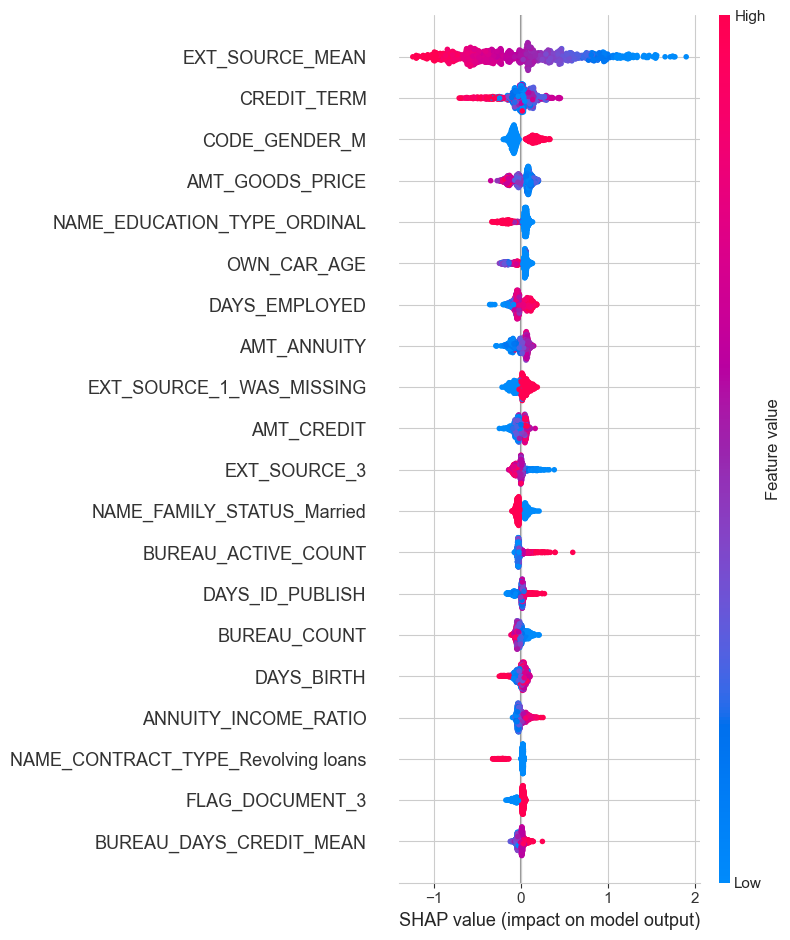

In [9]:
plt.figure()
shap.summary_plot(shap_values_pos, shap_sample, show=False)
plt.tight_layout()
plt.savefig('../figs/shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

EXT_SOURCE_MEAN dominates by a wide margin, so combined external bureau scores are the strongest predictor, low EXT_SOURCE_MEAN (blue) consistently pushes predictions toward higher default risk. 

CREDIT_TERM ranks second. 

Notably, CODE_GENDER_M shows a clear directional pattern (male applicants pushed toward higher risk), this warrants disparate impact testing per the finance background guide's fair lending guidance, to confirm the model isn't relying on gender as a discriminatory proxy rather than a legitimate risk signal.

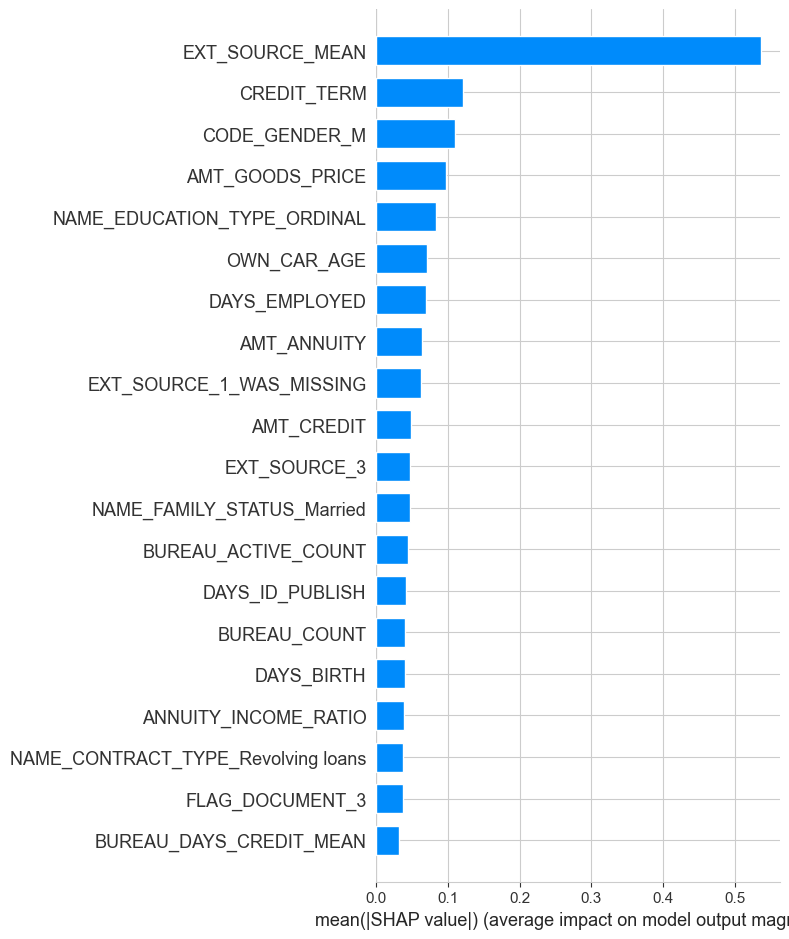

In [10]:
plt.figure()
shap.summary_plot(shap_values_pos, shap_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../figs/shap_bar_importance.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

The bar plot confirms the same feature ranking as the beeswarm plot, in a simpler format showing average impact magnitude regardless of direction. 

- EXT_SOURCE_MEAN's importance is 4.4x higher than the second-ranked feature (CREDIT_TERM), confirming it as the single dominant driver of model predictions.

## 4. Individual Applicant SHAP Waterfall Plots

One high-risk (PD > 0.5), one borderline (PD 0.2–0.4), one low-risk (PD < 0.1) applicant.

In [11]:
all_test_proba = best_model.predict_proba(X_test)[:, 1]
proba_series = pd.Series(all_test_proba, index=X_test.index)

high_risk_candidates = proba_series[proba_series > 0.5]
borderline_candidates = proba_series[(proba_series >= 0.2) & (proba_series <= 0.4)]
low_risk_candidates = proba_series[proba_series < 0.1]

print(f"High-risk candidates (PD>0.5): {len(high_risk_candidates)}")
print(f"Borderline candidates (0.2-0.4): {len(borderline_candidates)}")
print(f"Low-risk candidates (PD<0.1): {len(low_risk_candidates)}")

High-risk candidates (PD>0.5): 147
Borderline candidates (0.2-0.4): 4489
Low-risk candidates (PD<0.1): 45812


In [12]:

high_risk_idx = high_risk_candidates.index[0] if len(high_risk_candidates) > 0 else proba_series.idxmax()
borderline_idx = borderline_candidates.index[0] if len(borderline_candidates) > 0 else proba_series.iloc[(proba_series - 0.3).abs().argsort()[:1]].index[0]
low_risk_idx = low_risk_candidates.index[0] if len(low_risk_candidates) > 0 else proba_series.idxmin()

selected_indices = {
    'High-risk': high_risk_idx,
    'Borderline': borderline_idx,
    'Low-risk': low_risk_idx,
}
for label, idx in selected_indices.items():
    print(f"{label}: index={idx}, PD={proba_series[idx]:.4f}")

High-risk: index=173375, PD=0.5549
Borderline: index=103497, PD=0.2462
Low-risk: index=256571, PD=0.0638


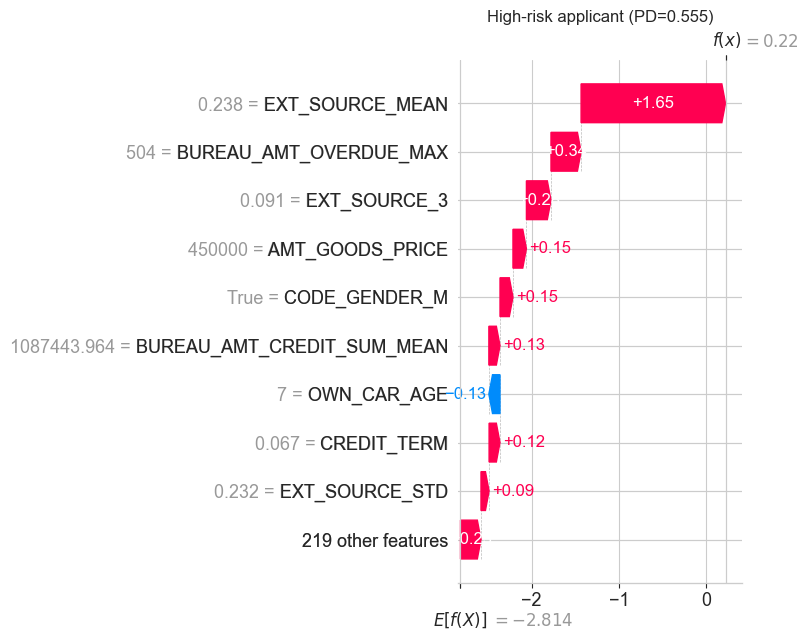

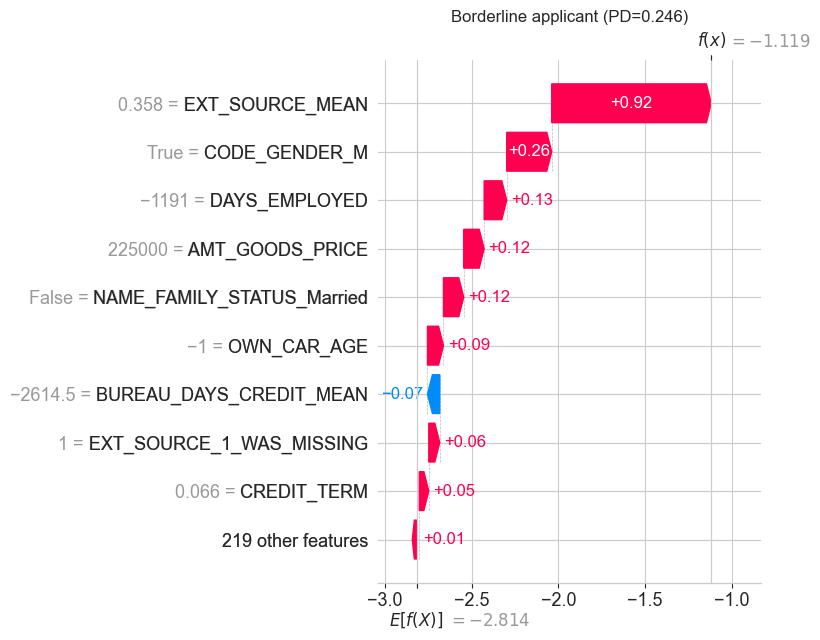

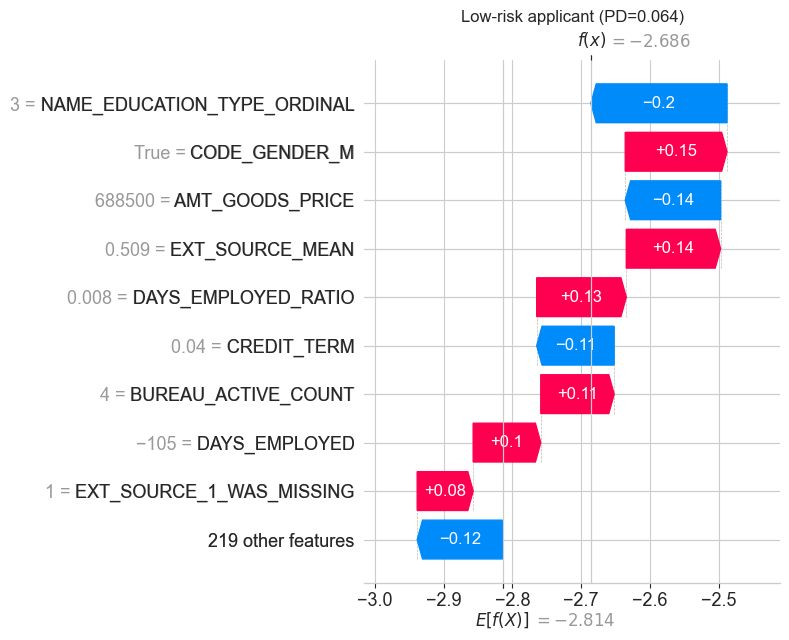

In [13]:
explainer_single = shap.TreeExplainer(best_model)

for label, idx in selected_indices.items():
    row = X_test.loc[[idx]]
    sv = explainer_single.shap_values(row)
    if isinstance(sv, list):
        sv_pos = sv[1]
        base_val = explainer_single.expected_value[1]
    else:
        sv_pos = sv
        base_val = explainer_single.expected_value

    explanation = shap.Explanation(
        values=sv_pos[0],
        base_values=base_val,
        data=row.iloc[0].values,
        feature_names=row.columns.tolist()
    )
    plt.figure()
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'{label} applicant (PD={proba_series[idx]:.3f})')
    plt.tight_layout()
    plt.savefig(f'../figs/shap_waterfall_{label.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
for label, idx in selected_indices.items():
    row = X_test.loc[[idx]]
    sv = explainer_single.shap_values(row)
    sv_pos = sv[1][0] if isinstance(sv, list) else sv[0]

    contributions = pd.Series(sv_pos, index=row.columns).sort_values(key=abs, ascending=False)
    top10 = contributions.head(10)

    result_table = pd.DataFrame({
        'feature': top10.index,
        'value': [row[feat].values[0] for feat in top10.index],
        'shap_contribution': top10.values.round(4)
    })

    print(f"\n=== {label} applicant (index={idx}, PD={proba_series[idx]:.4f}) ===")
    display(result_table)


=== High-risk applicant (index=173375, PD=0.5549) ===


,feature,value,shap_contribution
0,EXT_SOURCE_MEAN,0.238314,1.6539
1,BUREAU_AMT_OVERDUE_MAX,504.0,0.3446
2,EXT_SOURCE_3,0.091412,0.2814
3,AMT_GOODS_PRICE,450000.0,0.1540
4,CODE_GENDER_M,True,0.1483
5,BUREAU_AMT_CREDIT_SUM_MEAN,1087443.964286,0.1277
6,OWN_CAR_AGE,7.0,-0.1275
7,CREDIT_TERM,0.06712,0.1249
8,EXT_SOURCE_STD,0.232189,0.0927
9,AMT_ANNUITY,30204.0,0.0749



=== Borderline applicant (index=103497, PD=0.2462) ===


,feature,value,shap_contribution
0,EXT_SOURCE_MEAN,0.358323,0.9203
1,CODE_GENDER_M,True,0.2594
2,DAYS_EMPLOYED,-1191.0,0.1301
3,AMT_GOODS_PRICE,225000.0,0.1178
4,NAME_FAMILY_STATUS_Married,False,0.1167
5,OWN_CAR_AGE,-1.0,0.0922
6,BUREAU_DAYS_CREDIT_MEAN,-2614.5,-0.0707
7,EXT_SOURCE_1_WAS_MISSING,1,0.0632
8,CREDIT_TERM,0.065554,0.0547
9,EXT_SOURCE_2,0.030108,0.0533



=== Low-risk applicant (index=256571, PD=0.0638) ===


,feature,value,shap_contribution
0,NAME_EDUCATION_TYPE_ORDINAL,3,-0.1979
1,CODE_GENDER_M,True,0.1480
2,AMT_GOODS_PRICE,688500.0,-0.1386
3,EXT_SOURCE_MEAN,0.509327,0.1371
4,DAYS_EMPLOYED_RATIO,0.007774,0.1303
5,CREDIT_TERM,0.039825,-0.1126
6,BUREAU_ACTIVE_COUNT,4.0,0.1067
7,DAYS_EMPLOYED,-105.0,0.0983
8,EXT_SOURCE_1_WAS_MISSING,1,0.0814
9,AMT_ANNUITY,30676.5,0.0678


**Interpretation:**

Across all three applicants, EXT_SOURCE_MEAN remains the dominant factor, but its contribution scales with the applicant's actual score: +1.65 push toward risk for the high-risk applicant (score 0.238) vs. only +0.14 for the low-risk applicant (score 0.509), confirming the model's sensitivity to this feature is consistent and proportional across risk levels. 

The high-risk applicant's profile is compounded by a real prior delinquency (BUREAU_AMT_OVERDUE_MAX=504, +0.34). 

For the low-risk applicant, higher education (NAME_EDUCATION_TYPE_ORDINAL=3) is the single largest protective factor (-0.198), outweighing a moderate EXT_SOURCE_MEAN push toward risk. 

CODE_GENDER_M appears as a contributing risk factor across all three applicants (+0.15, +0.26, +0.15 respectively), reinforcing the need for disparate impact testing noted earlier.

In [15]:
# Predict on the full test set, apply the optimal threshold to get approve/decline decisions
full_test_proba = best_model.predict_proba(X_test)[:, 1]
decisions = (full_test_proba < best_thresh).astype(int)  # 1 = approved (low predicted risk), 0 = declined

gender_col = 'CODE_GENDER_M'
disparate_df = pd.DataFrame({
    'gender_male': X_test[gender_col].values,
    'approved': decisions
})

approval_rates = disparate_df.groupby('gender_male')['approved'].mean()
print("Approval rate by group:")
print(approval_rates)

ratio = approval_rates.min() / approval_rates.max()
print(f"\nAdverse impact ratio: {ratio:.3f} (should be ≥ 0.80 per the 80% rule)")
if ratio < 0.80:
    print("⚠️ POTENTIAL DISPARATE IMPACT — ratio below 0.80 threshold")
else:
    print("✓ Passes the 80% rule threshold")

Approval rate by group:
gender_male
False    0.908611
True     0.824881
Name: approved, dtype: float64

Adverse impact ratio: 0.908 (should be ≥ 0.80 per the 80% rule)
✓ Passes the 80% rule threshold


**Interpretation:**

The disparate impact test shows an approval rate of 90.9% for female applicants versus 82.5% for male applicants, yielding an adverse impact ratio of 0.908, above the 0.80 regulatory threshold. 

This means that despite CODE_GENDER_M consistently appearing as a risk-increasing factor in individual SHAP explanations, the model's aggregate approval decisions do not trigger the standard disparate impact test. This should still be documented and monitored going forward, since the underlying SHAP pattern suggests gender-correlated risk signals are present in the data (possibly via proxy variables), even though the current threshold and feature set don't produce disparate outcomes severe enough to fail the 80% rule.

## 5. Adverse Action Notice (High-Risk Applicant)

Per ECOA / the Canadian Human Rights Act and FCAC guidelines: list the top 4 factors contributing to the decline.

In [16]:
idx = selected_indices['High-risk']
row = X_test.loc[[idx]]
sv = explainer_single.shap_values(row)
sv_pos = sv[1][0] if isinstance(sv, list) else sv[0]

feature_impact = pd.Series(sv_pos, index=row.columns).sort_values(ascending=False)
top4_positive = feature_impact.head(4)  # most positive SHAP = pushed toward higher default risk

print(f"Adverse Action Notice — Applicant {idx} (Predicted PD: {proba_series[idx]:.3f})\n")
print("Top 4 factors contributing to elevated default risk:\n")
for i, (feat, impact) in enumerate(top4_positive.items(), 1):
    actual_value = row[feat].values[0]
    print(f"{i}. {feat} = {actual_value:.3f} (SHAP contribution: {impact:.4f})")

Adverse Action Notice — Applicant 173375 (Predicted PD: 0.555)

Top 4 factors contributing to elevated default risk:

1. EXT_SOURCE_MEAN = 0.238 (SHAP contribution: 1.6539)
2. BUREAU_AMT_OVERDUE_MAX = 504.000 (SHAP contribution: 0.3446)
3. EXT_SOURCE_3 = 0.091 (SHAP contribution: 0.2814)
4. AMT_GOODS_PRICE = 450000.000 (SHAP contribution: 0.1540)


## Adverse Action Notice

**Applicant:** Index 173375
**Decision:** Declined
**Predicted probability of default:** 55.5%

The following factors contributed most significantly to this decision:

1. **Low external credit bureau score** : Combined external bureau score of 0.238, below the approval threshold. This was the single largest factor in the decision.

2. **Prior payment delinquency** : A previous credit account shows a maximum overdue amount of $504, indicating a history of late or missed payments.

3. **Below-average secondary bureau score** — External bureau score #3 of 0.091, reinforcing the low overall creditworthiness signal.

4. **Loan amount relative to profile** — The requested loan is for goods valued at $450,000, which combined with the applicant's credit profile increases the assessed risk.

## 6. Population Stability Index (PSI)

Compare training and test distributions for the top 10 features by SHAP importance. PSI < 0.1 = stable; 0.1–0.25 = moderate shift; > 0.25 = significant shift.

In [17]:
def calculate_psi(expected, actual, buckets=10):
    """PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))"""
    expected = expected.astype(float)
    actual = actual.astype(float)

    breakpoints = np.linspace(0, 100, buckets + 1)
    bucket_edges = np.percentile(expected, breakpoints)
    bucket_edges[0] = -np.inf
    bucket_edges[-1] = np.inf
    bucket_edges = np.unique(bucket_edges)

    expected_counts = np.histogram(expected, bins=bucket_edges)[0]
    actual_counts = np.histogram(actual, bins=bucket_edges)[0]

    expected_pct = np.where(expected_counts == 0, 1e-4, expected_counts / len(expected))
    actual_pct = np.where(actual_counts == 0, 1e-4, actual_counts / len(actual))

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

mean_abs_shap = pd.Series(np.abs(shap_values_pos).mean(axis=0), index=shap_sample.columns)
top10_features = mean_abs_shap.sort_values(ascending=False).head(10).index.tolist()

psi_results = []
for feat in top10_features:
    psi_val = calculate_psi(X_train[feat].values, X_test[feat].values)
    psi_results.append({'feature': feat, 'PSI': psi_val})

psi_df = pd.DataFrame(psi_results).sort_values('PSI', ascending=False)
psi_df['flag'] = psi_df['PSI'].apply(lambda x: 'SIGNIFICANT SHIFT' if x > 0.25 else ('moderate' if x > 0.1 else 'stable'))
psi_df

,feature,PSI,flag
7,AMT_ANNUITY,0.000275,stable
1,CREDIT_TERM,0.000257,stable
6,DAYS_EMPLOYED,0.000238,stable
0,EXT_SOURCE_MEAN,0.000216,stable
9,AMT_CREDIT,0.000091,stable
3,AMT_GOODS_PRICE,0.000068,stable
4,NAME_EDUCATION_TYPE_ORDINAL,0.000049,stable
8,EXT_SOURCE_1_WAS_MISSING,0.000019,stable
5,OWN_CAR_AGE,0.000012,stable
2,CODE_GENDER_M,0.000010,stable


**Interpretation:**

All top 10 features show PSI values far below the 0.1 "stable" threshold (max 0.000275 for AMT_ANNUITY), confirming no meaningful distributional shift between train and test sets, expected, since both come from the same stratified random split of the same source data. 

This establishes a healthy baseline: in production, PSI should be recomputed periodically against new incoming applications (not just this train/test split) to detect genuine population drift over time. A PSI exceeding 0.25 on any of these top features in production would trigger a model review per the monitoring plan below.

## 7. Model Monitoring Dashboard

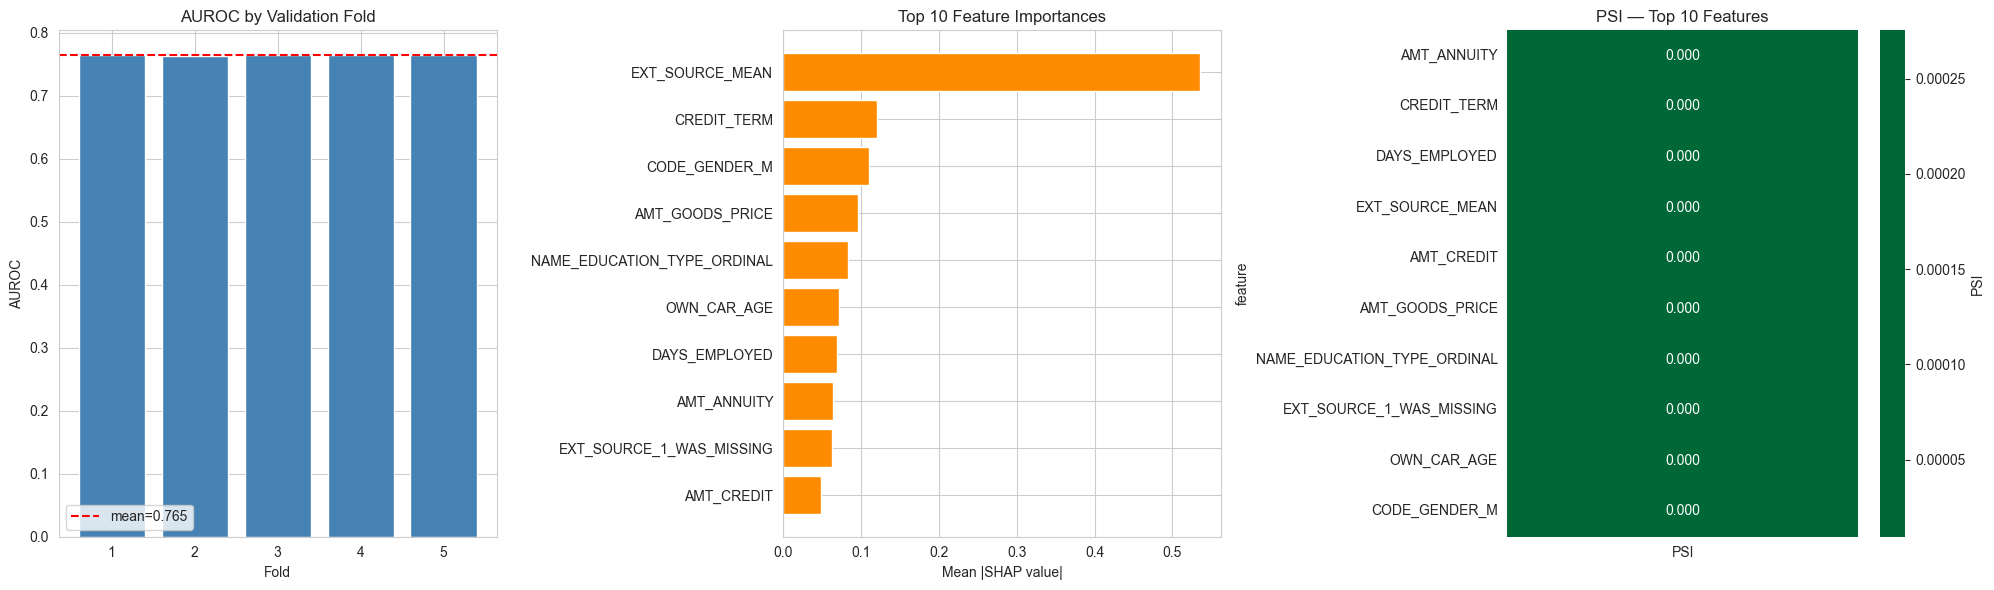

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].bar(range(1, len(cv_scores)+1), cv_scores, color='steelblue')
axes[0].axhline(cv_scores.mean(), color='red', linestyle='--', label=f'mean={cv_scores.mean():.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('AUROC')
axes[0].set_title('AUROC by Validation Fold')
axes[0].legend()

top10_shap = mean_abs_shap.sort_values(ascending=False).head(10)
axes[1].barh(top10_shap.index[::-1], top10_shap.values[::-1], color='darkorange')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Top 10 Feature Importances')

psi_matrix = psi_df.set_index('feature')[['PSI']]
sns.heatmap(psi_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r', center=0.1, ax=axes[2], cbar_kws={'label': 'PSI'})
axes[2].set_title('PSI — Top 10 Features')

plt.tight_layout()
plt.savefig('../figs/monitoring_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:**

The monitoring dashboard confirms the model is stable (AUROC consistently ~0.765 across folds), dominated by a single well-understood predictor (EXT_SOURCE_MEAN), and shows no distributional drift between train and test (all PSI ≈ 0). This establishes a healthy baseline snapshot.

**Monitoring plan (for final documentation):**
- Recompute PSI monthly against new production data for the top 10 SHAP features
- Trigger manual review if any feature's PSI exceeds 0.25
- Retrain if AUROC on a rolling recent sample drops below ~0.70 (vs. the 0.7678 baseline established here)
- Periodically re-run the disparate impact test on CODE_GENDER_M to ensure the 80% rule continues to be met as the applicant population evolves